Economic growth is far too commonly viewed as being an essential driver for improving living standards, however it is closely linked to rising carbon emissions, and with concerns for the climate an all-time high I believe it is time to question the necessity of this pollution we have become accustomed to. So, does becoming richer inevitably mean becoming less environmentally sustainable, or can economies grow while reducing their impact on the climate?
This project explores the relationship between economic growth and carbon dioxide (CO₂) emissions across four countries at different stages of development. By comparing China (developing), India (developing), the US (developed), and Germany (developed and more environmentally-focused), my analysis examines how this relationship changes when adjusted for population, efficiency, and time. The overall aim is to determine to what extent more developed economies are able to decouple economic growth from carbon dioxide emissions, by making use of data visualisation tools and modelling regressions.


In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
#importing data
co2_df = pd.read_csv("data_clean.csv")

co2_df.head()

,country,year,gdp,population,co2
0,China,2000,5.952680e+12,1.269581e+09,3643.809570
1,China,2001,6.329740e+12,1.278725e+09,3724.114258
2,China,2002,6.814490e+12,1.286867e+09,4098.180664
3,China,2003,7.248620e+12,1.294517e+09,4835.251465
4,China,2004,7.830950e+12,1.302100e+09,5210.961426


In [3]:
#checking column titles
co2_df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

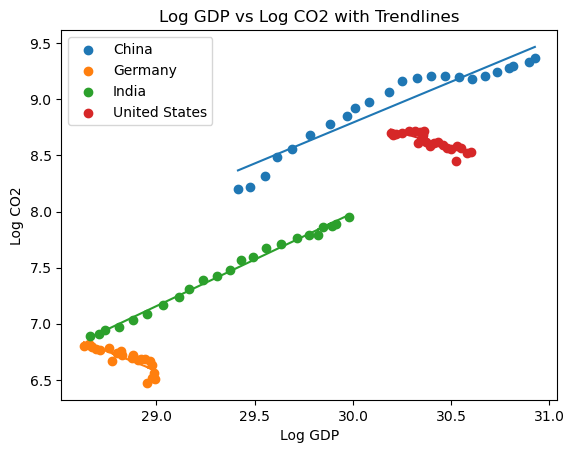

In [4]:
df = co2_df[["country", "year", "gdp", "population", "co2"]]

# Filter countries and years
countries = ["China", "India", "United States", "Germany"]
df = df[df["country"].isin(countries)]
df = df[df["year"] >= 2000]

# Remove bad data
df = df.dropna()
df = df[df["population"] > 0]

df.to_csv("data_clean.csv", index=False)

df["log_GDP"] = np.log(df["gdp"])
df["log_CO2"] = np.log(df["co2"])

for c in df["country"].unique():
    subset = df[df["country"] == c]
    
    x = subset["log_GDP"]
    y = subset["log_CO2"]
    
    plt.scatter(x, y, label=c)
    
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)

plt.xlabel("Log GDP")
plt.ylabel("Log CO2")
plt.title("Log GDP vs Log CO2 with Trendlines")
plt.legend()
plt.show()

Figure 1 shows the relationship between total GDP and total CO₂ emissions for each country. A strong positive relationship can be seen clearly for China and India (the developing economies), as demonstrated by the blue and green trendlines. This shows that increases in economic output are tightly matched by rising carbon dioxide emissions, which reflects large-scale industrialisation and expansion.
In contrast, the data for Germany and the United States leads to much flatter or even slightly negative trendlines, indicating that despite continued economic growth, emissions have plateaued or even decreased. This suggests that the link between GDP and emissions is weaker in more developed economies, especially in Germany.
However, total measures are heavily influenced a country’s size, as larger economies naturally produce more output and emissions. Consequently, this graph does not fully reflect environmental efficiency, making it necessary to consider per capita measures.


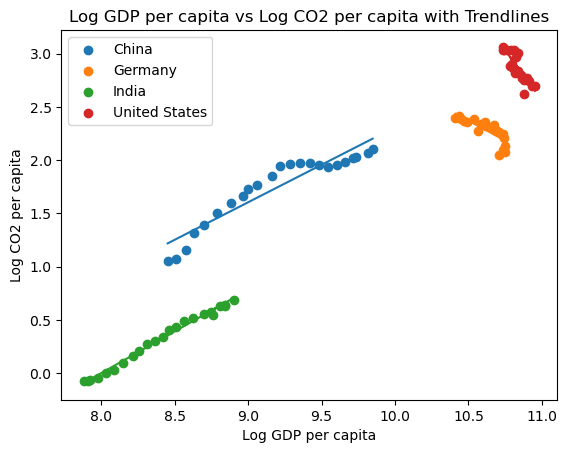

In [5]:
df["gdp_per_capita"] = df["gdp"] / df["population"]
df["co2_per_capita"] = (df["co2"] * 1_000_000) / df["population"]

df["log_GDP_pc"] = np.log(df["gdp_per_capita"])
df["log_CO2_pc"] = np.log(df["co2_per_capita"])

for c in df["country"].unique():
    subset = df[df["country"] == c]
    
    x = subset["log_GDP_pc"]
    y = subset["log_CO2_pc"]
    
    plt.scatter(x, y, label=c)
    
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)

plt.xlabel("Log GDP per capita")
plt.ylabel("Log CO2 per capita")
plt.title("Log GDP per capita vs Log CO2 per capita with Trendlines")
plt.legend()
plt.show()

Figure 2 shows the relationship between GDP per capita and CO₂ emissions per capita, removing the bias caused by population size. A divergence clearly emerges between developing and developed economies, where China and India continue to show strong positive relationships, indicating that increases in income are associated with rising emissions. This suggests that economic growth in these countries remains closely tied to energy use and industrial activity.
In contrast, Germany and the United States display weak or negative relationships, with emissions per capita remaining stable or declining as income rises. This indicates that development past a certain point may be the key to allowing economies to grow without increasing emissions. This figure provides initial evidence of decoupling between economic growth and emissions in more developed countries.


In [6]:
corrs = []

for c in df["country"].unique():
    subset = df[df["country"] == c]
    corr = subset["gdp_per_capita"].corr(subset["co2_per_capita"])
    corrs.append([c, round(corr, 3)])

corr_df = pd.DataFrame(corrs, columns=["Country", "Correlation"])
corr_df.index = range(1, len(corr_df) + 1)
corr_df

,Country,Correlation
1,China,0.913
2,Germany,-0.830
3,India,0.992
4,United States,-0.837


These correlation results provide further support for the patterns shown in Figure 2. China and India exhibit strong positive correlations (>0.9), indicating that increases in GDP per capita are closely associated with higher CO₂ emissions per capita. This provides quantitative evidence backing up the idea that economic growth in developing economies remains closely linked to emissions.
In contrast, Germany and the United States show strong negative correlations (<-0.8), suggesting that emissions per capita tend to decrease as income rises beyond a certain level. This complete 180 in the direction of the relationship highlights a clear difference between developing and developed economies, and provides further evidence of decoupling at higher levels of development. 


In [7]:
import statsmodels.api as sm

results = []

for c in df["country"].unique():
    subset = df[df["country"] == c]
    
    X = subset["log_GDP_pc"]
    y = subset["log_CO2_pc"]
    
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    slope = model.params["log_GDP_pc"]
    intercept = model.params["const"]
    r2 = model.rsquared
    
    results.append([c, slope, intercept, r2])

reg_df = pd.DataFrame(results, columns=["Country", "Slope (Elasticity)", "Intercept", "R²"])

reg_df = reg_df.round(3)
reg_df.index = range(1, len(reg_df) + 1)
reg_df.index.name = None

reg_df

,Country,Slope (Elasticity),Intercept,R²
1,China,0.704,-4.736,0.886
2,Germany,-0.742,10.156,0.631
3,India,0.783,-6.262,0.990
4,United States,-1.882,23.266,0.710


Running a regression analysis provides a more formal measure of the relationship between income and emissions. The coefficients produced by running a log-log model can be interpreted as elasticities, showing the percentage change in CO₂ emissions per capita associated with a 1% increase in GDP per capita.
The results show positive elasticities for China (0.704) and India (0.783), further reinforcing the idea that economic growth is associated with rising emissions in developing countries. On the opposite end of the scale though, Germany and the United States exhibit negative elasticities (-0.742 and -1.882, respectively), indicating that emissions decline as income increases once an economy has surpassed a certain threshold. This provides meaningful evidence that the relationship between income and emissions reverses at higher levels of development.
R² measures the proportion of variation in emissions explained by changes in income. These values suggest that the model fits well for India (0.990) and China (0.886), indicating a tight and consistent relationship. Lower values for Germany (0.631) and the United States (0.710) suggest that the relationship becomes more complex in developed economies, where additional factors may influence emissions.


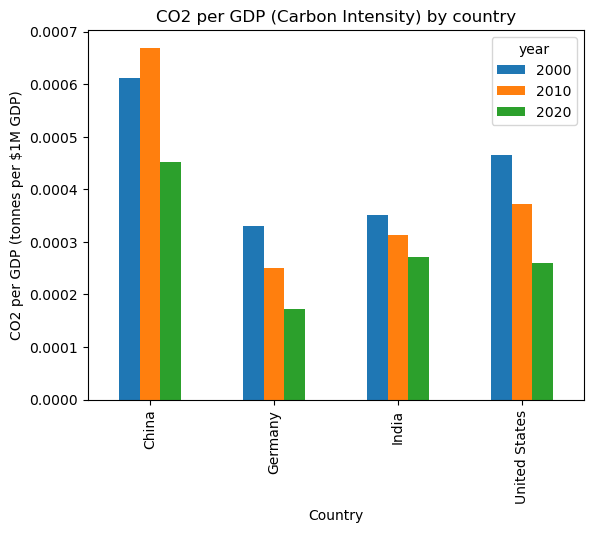

In [8]:
df["co2_per_gdp"] = df["co2"] / df["gdp"]

years = [2000, 2010, 2020]
df_years = df[df["year"].isin(years)]

comparison = df_years[["country", "year", "co2_per_gdp"]]
comparison = comparison.sort_values(["year", "country"])

comparison

table = comparison.pivot(index="country", columns="year", values="co2_per_gdp")
table = table * 1_000_000

table.plot(kind="bar")
plt.title("CO2 per GDP (Carbon Intensity) by country")
plt.ylabel("CO2 per GDP (tonnes per $1M GDP)")
plt.xlabel("Country")
plt.show()

Carbon intensity, measured by CO₂ emissions per GDP, provides a clear comparison of how efficiently economies generate output compared with their environmental impact. Figure 5 shows an explicit downward trend in carbon intensity across all four countries between the years 2000 and 2020, indicating that economic growth has become less emissions-intensive over time – potentially caused by new technologies, regulations or shifting industries.
Germany consistently exhibits the lowest carbon intensity, suggesting a high level of environmental efficiency. The United States also shows a substantial decline, although it remains more carbon-intensive than Germany, potentially due to the aforementioned bias caused by it being a larger country. China, despite starting from the highest level, demonstrates the largest absolute reduction, reflecting significant improvements in efficiency during its period of rapid industrialisation. India, similarly, follows a downward trend but at a more gradual rate.
Overall, these results suggest that while emissions may still rise in some economies - particularly those still developing - output is increasing at a faster rate, leading to global improvements in environmental efficiency.


In [9]:
df_2000 = df[df["year"] == 2000]
df_2020 = df[df["year"] == 2020]

merged = df_2000.merge(df_2020, on="country", suffixes=("_2000", "_2020"))

merged["gdp_change_%"] = (merged["gdp_per_capita_2020"] / merged["gdp_per_capita_2000"] - 1) * 100
merged["co2_change_%"] = (merged["co2_per_capita_2020"] / merged["co2_per_capita_2000"] - 1) * 100

# efficiency (CO2 per GDP)
merged["efficiency_change_%"] = (
    (merged["co2_per_capita_2020"] / merged["gdp_per_capita_2020"]) /
    (merged["co2_per_capita_2000"] / merged["gdp_per_capita_2000"]) - 1
) * 100

result = merged[["country", "gdp_change_%", "co2_change_%", "efficiency_change_%"]].round(1)

result.index = range(1, len(result) + 1)
result.columns = ["Country", "GDP % Change", "CO2 % Change", "Efficiency % Change"]
result

,Country,GDP % Change,CO2 % Change,Efficiency % Change
1,China,261.2,166.2,-26.3
2,Germany,34.7,-29.6,-47.7
3,India,140.6,85.1,-23.0
4,United States,15.5,-35.4,-44.1


Figure 6 shows a table comparing percentage change in each country between 2000 and 2020, providing clear evidence of how economic growth, emissions, and efficiency have evolved across different economies. China and India experienced substantial increases in GDP per capita (261% and 141% respectively), alongside significant rises in CO₂ emissions (166% and 85%), indicating that economic growth remains closely linked to emissions in developing economies.
However, all countries show a decrease in carbon intensity, reflecting improvements in efficiency over time. China and India became more efficient by approximately 26% and 23%, respectively, although these gains were not sufficient to offset the increase in emissions driven by rapid growth. In contrast, Germany and the United States achieved both efficiency improvements (47.7% and 44.1%) and reductions in emissions, with CO₂ per capita falling by 29.6% and 35.4% respectively.
What this data shows is that, despite all of the economies investigated becoming more efficient, only developed economies appear to be able to translate these efficiency gains into a net reduction of emissions, which provides strong evidence that emissions and GDP can be decoupled.


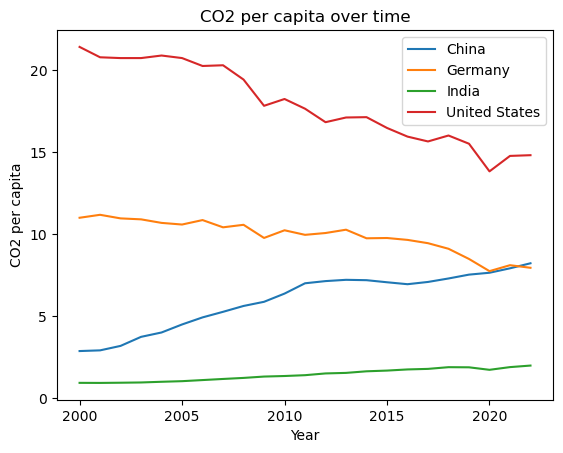

In [10]:
for c in df["country"].unique():
    subset = df[df["country"] == c]
    plt.plot(subset["year"], subset["co2_per_capita"], label=c)

plt.xlabel("Year")
plt.ylabel("CO2 per capita")
plt.title("CO2 per capita over time")
plt.legend()
plt.show()

Figure 7 shows how both China and India have experienced a steady increase in emissions per capita, which reflects both continuing industrial growth as well as rising energy demands. In contrast, both Germany and the United States are experiencing a downward trend, with emissions falling despite also experiencing industrial growth.
These trends line up with earlier findings: developing economies experience rising emissions alongside economic growth, while with a developed economy it is possible to reduce emissions while maintaining economic growth. It is worth noting, however, that despite China's increasing emissions, it's per capita emissions remain below those of the United States, which suggests differences in stages of development as well as consumption habits.
Overall, Figure 7 provides strong evidence of the difference between developing and developed countries, which supports the conclusion that, despite efficiency improvements being generally widespread, it is only in developed countries that we see sustained reductions in overall emissions.


The goal of this analysis was to investigate the relationship between emissions and economic growth, and whether it is inevitable that a stronger economy necessarily leads to increased carbon emissions, or if a more developed economy is able to maintain growth while reducing environmental impact. The results of the collected data show that there is a clear distinction between developed and developing economies. China and India, both developing economies, show a strong positive correlation between emissions and economic growth, meanwhile Germany and the United States, which are both developed economies, display evidence of decoupling, with emissions declining even with increased economic growth.
While most, if not all, economies have improved their overall efficiency, as shown by a reduction in carbon intensity, these improvements have only led into an absolute reduction in emissions for more developed economies. This suggests that, while it is possible for economic growth to continue without demanding an increase in emissions to go along with it, this depends on several factors such as the composition of the economy, methods a country may use to generate energy, and the technological development of the economy.
Overall, the findings made in this essay suggest that as economies continue to develop, it becomes more possible to reduce the impact of the economy on the environment, without sacrificing economic growth. Achieving this, however, may require a significant change in how energy is both produced and consumed. This highlights the importance of innovation, as well as long term policy and structural change to tackle the challenges of climate change.
